<a href="https://colab.research.google.com/github/Saiful-2/forest-cover-classification/blob/main/notebooks/8_forest_shap_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 What is SHAP (Simple Understanding)

👉 SHAP = SHapley Additive exPlanations

👉 It tells:

“Why did the model make this prediction?”

✔ Not just what → but WHY
## 🧱 STEP 1: Install & Import Libraries

In [1]:
!pip install shap

In [2]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

## 📥 STEP 2: Load Dataset

In [3]:
url = "https://raw.githubusercontent.com/Saiful-2/datasets/main/forest_cleaned_dataset.csv"
df = pd.read_csv(url)

df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type,Soil_Sum
0,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,0,0,1,0,0,1,1
1,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,0,2,1
2,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,0,2,1
3,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,2,1
4,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,2,1


## STEP 3: Define Features & Target

In [4]:
X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]

## STEP 4: Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## STEP 5: Train Random Forest Model

In [6]:
rf = RandomForestClassifier(
    n_estimators=50,   # reduced (important)
    max_depth=10,      # optional (faster)
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42)

## STEP 6: Take SMALL SAMPLE (CRITICAL STEP)

In [7]:
X_sample = X_test.sample(5000, random_state=42)

This solves our execution problem

## STEP 7: Create SHAP Explainer (FAST)

In [8]:
explainer = shap.TreeExplainer(rf)

## STEP 8: Calculate SHAP Values (NOW FAST)

In [9]:
shap_values = explainer.shap_values(X_sample)

## STEP 9: SHAP Summary Plot (MAIN ONE)

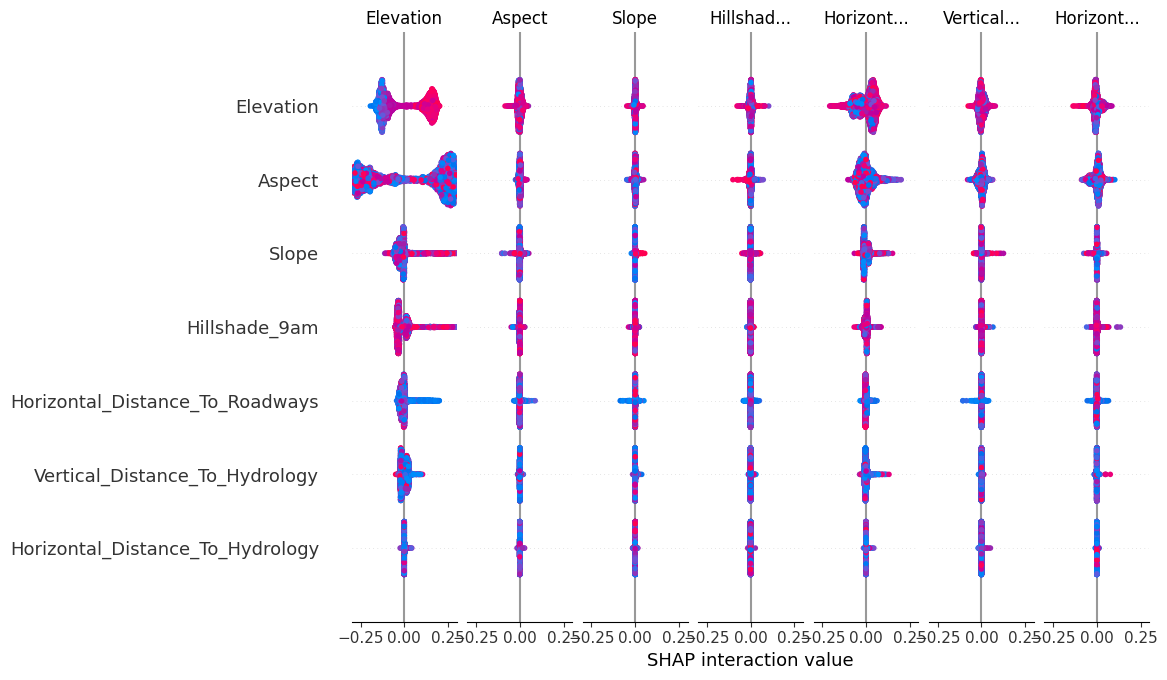

In [10]:
shap.summary_plot(shap_values, X_sample)

## Interpretation
Top features = most important

Red = high value, Blue = low value

Shows how features impact prediction

## STEP 10: Bar Plot (Simple & Clean)

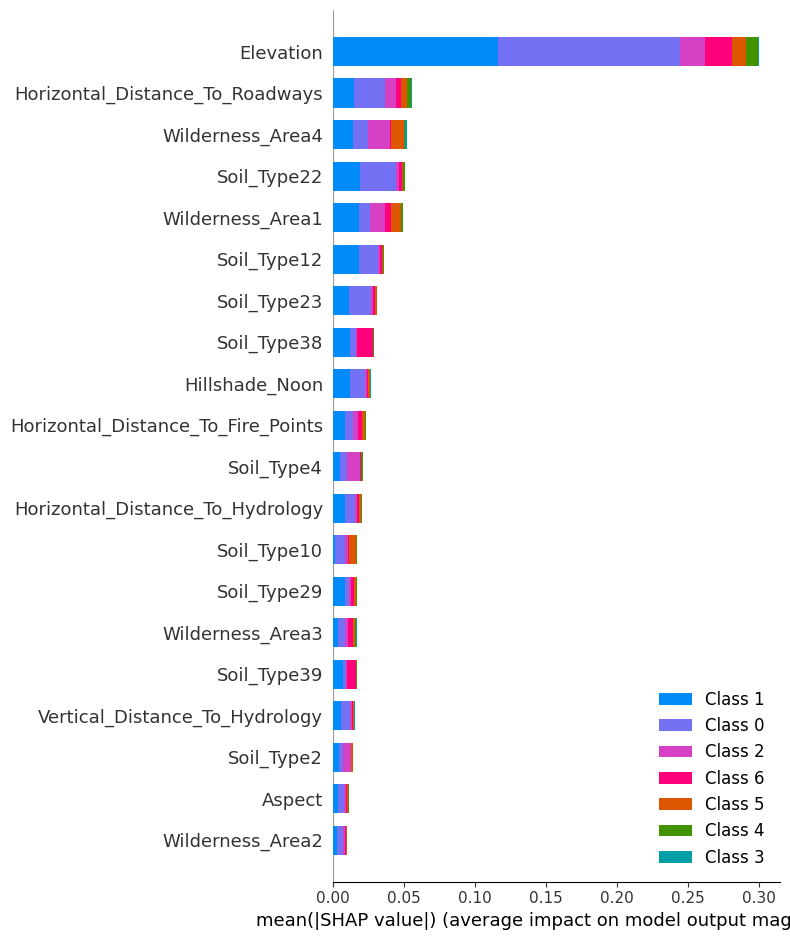

In [11]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

## FINAL INSIGHT

"SHAP analysis revealed that elevation, soil type, and distance-based features are the most influential factors in predicting forest cover type. A sample-based approach was used to efficiently compute SHAP values."

### Why did you use sample?

👉 Answer:

"SHAP is computationally expensive, so I used a representative sample of 100 observations to efficiently interpret the model without losing meaningful insights."